In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [2]:
# ============================================================
# 프로젝트 경로 설정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정
# ============================================================

ROOT = Path(r"C:\Users\박정수\OneDrive\바탕 화면\공모전\Anti-Churn-Committee")

DATA_RAW_DIR = ROOT / "data" / "raw"
DATA_PROCESSED_DIR = ROOT / "data" / "processed"

USER_PROFILE_FILE = "01_user_profile_preprocessed.csv"
EVENT_LOG_FILE = "02_event_log_preprocessed.csv"

USER_PROFILE_PATH = DATA_PROCESSED_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_PROCESSED_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)

USER_PROFILE_PATH: C:\Users\박정수\OneDrive\바탕 화면\공모전\Anti-Churn-Committee\data\processed\01_user_profile_preprocessed.csv
EVENT_LOG_PATH   : C:\Users\박정수\OneDrive\바탕 화면\공모전\Anti-Churn-Committee\data\processed\02_event_log_preprocessed.csv


In [3]:
df_raw01 = pd.read_csv(USER_PROFILE_PATH)
df_raw02 = pd.read_csv(EVENT_LOG_PATH)

print("df_raw01 shape:", df_raw01.shape)
print("df_raw02 shape:", df_raw02.shape)

display(df_raw01.head())
display(df_raw02.head())

df_raw01 shape: (12500, 23)
df_raw02 shape: (1757262, 11)


,user_id,signup_date,signup_channel,device,notification_agreed,notification_changed_date,signup_day,signup_month,signup_weekday,first_event_time,first_event_elapsed_hours,first_app_launch_time,app_launch_elapsed_hours,onboarding_completed_time,onboarding_elapsed_hours,app_launch_to_onboarding_hours,is_onboarding_completed,event_count_total,avg_events_per_session,is_signup_log_issue_period,is_no_event_user,is_notification_changed,is_first_event_before_signup
0,U0000001,2025-01-25,오가닉,iOS,True,NaN,2025-01-25,2025-01,토,2025-01-25 07:25:45,7.429167,2025-01-25 07:25:45,7.429167,2025-01-25 07:26:15,7.437500,0.008333,True,515,2.07,False,False,False,False
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,화,2025-05-06 16:23:12,16.386667,2025-05-06 16:23:12,16.386667,NaN,NaN,NaN,False,55,2.62,False,False,True,False
2,U0000003,2025-05-14,오가닉,iOS,False,NaN,2025-05-14,2025-05,수,2025-05-14 11:09:58,11.166111,2025-05-14 11:09:58,11.166111,NaN,NaN,NaN,False,3,1.50,False,False,False,False
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN,2025-02-23,2025-02,일,2025-02-23 07:15:35,7.259722,2025-02-23 07:15:35,7.259722,NaN,NaN,NaN,False,89,1.79,False,False,False,False
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN,2025-02-18,2025-02,화,2025-02-18 12:50:01,12.833611,2025-02-18 12:52:37,12.876944,2025-02-18 12:53:07,12.885278,0.008333,True,442,1.85,False,False,False,False


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,토,7,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,토,20,False,False


In [4]:
# ============================================================
# 원본 데이터 구조 확인
# ============================================================

print("User_Profile 컬럼")
print(df_raw01.columns.tolist())

print("\nEvent_Log 컬럼")
print(df_raw02.columns.tolist())

print("\nUser_Profile 결측치")
display(df_raw01.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nEvent_Log 결측치")
display(df_raw02.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\n중복 확인")
print("User_Profile 전체 중복 행:", df_raw01.duplicated().sum())
print("Event_Log 전체 중복 행    :", df_raw02.duplicated().sum())

User_Profile 컬럼
['user_id', 'signup_date', 'signup_channel', 'device', 'notification_agreed', 'notification_changed_date', 'signup_day', 'signup_month', 'signup_weekday', 'first_event_time', 'first_event_elapsed_hours', 'first_app_launch_time', 'app_launch_elapsed_hours', 'onboarding_completed_time', 'onboarding_elapsed_hours', 'app_launch_to_onboarding_hours', 'is_onboarding_completed', 'event_count_total', 'avg_events_per_session', 'is_signup_log_issue_period', 'is_no_event_user', 'is_notification_changed', 'is_first_event_before_signup']

Event_Log 컬럼
['user_id', 'event_time', 'event_type', 'session_id', 'notification_type', 'event_date', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period', 'is_event_type_missing']

User_Profile 결측치


,missing_count
notification_changed_date,10524
app_launch_to_onboarding_hours,6784
onboarding_completed_time,6781
onboarding_elapsed_hours,6781
signup_channel,137
device,121
notification_agreed,116
app_launch_elapsed_hours,53
first_app_launch_time,53
first_event_elapsed_hours,47



Event_Log 결측치


,missing_count
notification_type,1538380
session_id,241502
event_type,26456
event_time,0
user_id,0
event_date,0
event_month,0
event_weekday,0
event_hour,0
is_log_issue_period,0



중복 확인
User_Profile 전체 중복 행: 0
Event_Log 전체 중복 행    : 0


In [5]:
user_df = df_raw01.copy()
event_df = df_raw02.copy()

In [6]:
def convert_date_columns(df, date_cols):
    result = df.copy()

    for col in date_cols:
        result[col] = pd.to_datetime(
            result[col],
            errors="coerce"
        )

    return result

In [7]:
user_date_cols = [
    "signup_date",
    "notification_changed_date",
    "first_event_time",
    "first_app_launch_time",
    "onboarding_completed_time"
]

event_date_cols = [
    "event_time",
    "event_date"
]


user_df = convert_date_columns(
    user_df,
    user_date_cols
)

event_df = convert_date_columns(
    event_df,
    event_date_cols
)

In [8]:
print("전체 이벤트 수: ", len(event_df))
print('session_id 결측 이벤트 수: ', event_df['session_id'].isna().sum())

print("session_id 결측 이벤트 비율: ", (event_df['session_id'].isna().sum() / len(event_df) * 100).round(2), "%")

전체 이벤트 수:  1757262
session_id 결측 이벤트 수:  241502
session_id 결측 이벤트 비율:  13.74 %


---

세션 분석용 데이터 만들기

In [9]:
# 세션 아이디가 부여된 이벤트만 추출
session_df = event_df[
    event_df["session_id"].notna()
].copy()

In [10]:
# 세션 아이디가 부여된 이벤트에서 event_type 결측치를 "알수없음"으로 채움
session_df["event_type"] = (
    session_df["event_type"]
    .fillna("알수없음")
)

In [11]:
# 같은 사용자가 앱을 몇번 실행했는지 확인
user_session_count = (
    session_df
    .groupby("user_id")
    .agg(
        세션수=("session_id", "nunique")
    )
    .reset_index()
)

In [12]:

user_session_count["세션수"].describe()

count    12451.000000
mean        59.134286
std         72.022695
min          1.000000
25%          8.000000
50%         21.000000
75%         92.000000
max        262.000000
Name: 세션수, dtype: float64

In [13]:
#세션이이디 당 사용자, 세션 시작 시간, 세션 종료 시간, 세션 이벤트 수, 고유 이벤트 타입 수를 집계

session_summary = (
    session_df
    .groupby("session_id")
    .agg(
        user_id=("user_id", "first"),
        세션시작시간=("event_time", "min"),
        세션종료시간=("event_time", "max"),
        세션이벤트수=("event_type", "size"),
    )
    .reset_index()
)

In [14]:
session_summary

,session_id,user_id,세션시작시간,세션종료시간,세션이벤트수
0,000002f75f,U0002305,2025-06-14 14:52:23,2025-06-14 14:52:53,2
1,000031132c,U0002269,2025-02-26 20:01:04,2025-02-26 20:01:34,2
2,0000378282,U0007464,2025-05-03 21:03:02,2025-05-03 21:05:46,3
3,00003dd90e,U0010821,2025-04-05 18:19:23,2025-04-05 18:19:53,2
4,0000495a5e,U0007285,2025-04-03 21:54:41,2025-04-03 21:55:53,3
...,...,...,...,...,...
736276,ffffcefcdc,U0006209,2025-01-07 12:47:23,2025-01-07 12:50:28,4
736277,ffffe5a6da,U0012094,2025-05-09 16:50:37,2025-05-09 16:56:30,6
736278,ffffe5f996,U0007837,2025-02-25 07:37:05,2025-02-25 07:37:05,1
736279,fffff122cd,U0001372,2025-03-29 15:56:37,2025-03-29 15:56:37,1


In [15]:
duplicate_summary = (
    session_df
    .groupby(
        ["session_id", "event_type"]
    )
    .size()
    .reset_index(name="발생횟수")
)

duplicate_summary = duplicate_summary[
    duplicate_summary["발생횟수"] > 1
].sort_values(
    "발생횟수",
    ascending=False
)

display(duplicate_summary)

,session_id,event_type,발생횟수
1448477,f4b462173c,알수없음,3
1321023,df0ba082be,알수없음,2
118760,141d95b5f8,알수없음,2
2719,0075341c98,알수없음,2
1336241,e19c9c3343,알수없음,2
...,...,...,...
77858,0d29467a8d,알수없음,2
78069,0d322abe8d,알수없음,2
84157,0e3f17b9e3,알수없음,2
106347,1204f9e426,알수없음,2


In [16]:
duplicate_summary["event_type"].value_counts().head(20)

event_type
알수없음    259
Name: count, dtype: int64

> 이벤트 타입에 결측치(알수없음) 제외 하고 중복이 없는 것을 확인

# 세션 이용시간

In [17]:
# 세션당 이용시간(분) 계산

session_summary["세션이용시간_분"] = (
    session_summary["세션종료시간"]
    - session_summary["세션시작시간"]
).dt.total_seconds() / 60

session_summary["세션이용시간_분"] = (
    session_summary["세션이용시간_분"]
    .round(2)
)

In [18]:
session_summary.head(20)

,session_id,user_id,세션시작시간,세션종료시간,세션이벤트수,세션이용시간_분
0,000002f75f,U0002305,2025-06-14 14:52:23,2025-06-14 14:52:53,2,0.50
1,000031132c,U0002269,2025-02-26 20:01:04,2025-02-26 20:01:34,2,0.50
2,0000378282,U0007464,2025-05-03 21:03:02,2025-05-03 21:05:46,3,2.73
3,00003dd90e,U0010821,2025-04-05 18:19:23,2025-04-05 18:19:53,2,0.50
4,0000495a5e,U0007285,2025-04-03 21:54:41,2025-04-03 21:55:53,3,1.20
5,000063ece4,U0011942,2025-03-01 09:30:41,2025-03-01 09:30:41,1,0.00
6,000083c9f0,U0009090,2025-04-06 18:00:49,2025-04-06 18:00:49,1,0.00
7,000088d0c9,U0005429,2025-04-28 22:02:27,2025-04-28 22:02:27,1,0.00
8,00008d3615,U0000474,2025-02-22 08:19:53,2025-02-22 08:19:53,1,0.00
9,0000a0a37c,U0007157,2025-04-20 17:32:27,2025-04-20 17:32:57,2,0.50


In [19]:
session_summary['세션이용시간_분'].describe()

count    736281.000000
mean          0.901853
std           1.279585
min           0.000000
25%           0.000000
50%           0.500000
75%           1.220000
max          16.270000
Name: 세션이용시간_분, dtype: float64

유저들의 이용시간이 그지 길지 않은편이다.

평균 이용시간이 1분이 채 되지않으며 

> 가장 길게 이용한 유저 또한 약 16분 이용한 상태이다.

# 세션당 이벤트 타입 발생 횟수

In [20]:
session_event_count =(
    session_df
    .groupby(
        ["session_id", "event_type"]
    )
    .size()
    .reset_index(name= '이벤트수')
)

In [21]:
display(session_event_count.head(20))

,session_id,event_type,이벤트수
0,000002f75f,수면기록,1
1,000002f75f,앱실행,1
2,000031132c,수면기록,1
3,000031132c,앱실행,1
4,0000378282,앱실행,1
5,0000378282,챌린지_탐색,1
6,0000378282,챌린지참여,1
7,00003dd90e,수면기록,1
8,00003dd90e,앱실행,1
9,0000495a5e,마음챙김,1


In [22]:
session_event_count['event_type'].value_counts().head(20)

event_type
앱실행       718047
수면기록      239437
운동기록      129304
마음챙김      128430
식단기록       99833
챌린지참여      95375
챌린지_탐색     76910
알수없음       22520
온보딩_완료      5644
Name: count, dtype: int64

# 한 세션안에 이벤트 타입 비율

In [23]:
session_event_count["세션전체이벤트수"] = (
    session_event_count
    .groupby("session_id")["이벤트수"]
    .transform("sum")
)

In [24]:
session_event_count["세션내이벤트비율"] = (
    session_event_count["이벤트수"]
    / session_event_count["세션전체이벤트수"]
    * 100
).round(2)

In [25]:
display(
    session_event_count
    .sort_values(
        [
            "session_id",
            "세션내이벤트비율"
        ],
        ascending=[True, False]
    )
    .head(30)
)

,session_id,event_type,이벤트수,세션전체이벤트수,세션내이벤트비율
0,000002f75f,수면기록,1,2,50.00
1,000002f75f,앱실행,1,2,50.00
2,000031132c,수면기록,1,2,50.00
3,000031132c,앱실행,1,2,50.00
4,0000378282,앱실행,1,3,33.33
5,0000378282,챌린지_탐색,1,3,33.33
6,0000378282,챌린지참여,1,3,33.33
7,00003dd90e,수면기록,1,2,50.00
8,00003dd90e,앱실행,1,2,50.00
9,0000495a5e,마음챙김,1,3,33.33


# 전체 세션 중 이벤트 타입 포함 비율

In [26]:
session_event_presence = (
    session_df[
        [
            "session_id",
            "event_type"
        ]
    ]
    .drop_duplicates()
)

In [27]:
total_session_count = (
    session_df["session_id"]
    .nunique()
)

# 이벤트타입별 발ㄹ생 세션 수를 계산

In [28]:
event_session_summary = (
    session_event_presence
    .groupby("event_type")
    .agg(
        포함세션수=("session_id", "nunique")
    )
    .reset_index()
)

In [29]:
event_session_summary["세션포함비율"] = (
    event_session_summary["포함세션수"]
    / total_session_count
    * 100
).round(2)

event_session_summary = (
    event_session_summary
    .sort_values(
        "세션포함비율",
        ascending=False
    )
)

In [30]:
event_session_summary

,event_type,포함세션수,세션포함비율
4,앱실행,718047,97.52
1,수면기록,239437,32.52
6,운동기록,129304,17.56
0,마음챙김,128430,17.44
2,식단기록,99833,13.56
8,챌린지참여,95375,12.95
7,챌린지_탐색,76910,10.45
3,알수없음,22520,3.06
5,온보딩_완료,5644,0.77


#  세션 × 이벤트 타입 피벗

In [31]:
session_event_pivot = pd.crosstab(
    index=session_df["session_id"],
    columns=session_df["event_type"]
).reset_index()

In [32]:
session_event_pivot

event_type,session_id,마음챙김,수면기록,식단기록,알수없음,앱실행,온보딩_완료,운동기록,챌린지_탐색,챌린지참여
0,000002f75f,0,1,0,0,1,0,0,0,0
1,000031132c,0,1,0,0,1,0,0,0,0
2,0000378282,0,0,0,0,1,0,0,1,1
3,00003dd90e,0,1,0,0,1,0,0,0,0
4,0000495a5e,1,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
736276,ffffcefcdc,1,0,0,0,1,0,0,1,1
736277,ffffe5a6da,1,0,1,0,1,0,1,1,1
736278,ffffe5f996,0,0,0,0,1,0,0,0,0
736279,fffff122cd,0,0,0,0,1,0,0,0,0


# 결과 확인

In [33]:
print(
    f"전체 세션 수: {total_session_count:,}개"
)

display(event_session_summary)
display(session_event_pivot.head())

전체 세션 수: 736,281개


,event_type,포함세션수,세션포함비율
4,앱실행,718047,97.52
1,수면기록,239437,32.52
6,운동기록,129304,17.56
0,마음챙김,128430,17.44
2,식단기록,99833,13.56
8,챌린지참여,95375,12.95
7,챌린지_탐색,76910,10.45
3,알수없음,22520,3.06
5,온보딩_완료,5644,0.77


event_type,session_id,마음챙김,수면기록,식단기록,알수없음,앱실행,온보딩_완료,운동기록,챌린지_탐색,챌린지참여
0,000002f75f,0,1,0,0,1,0,0,0,0
1,000031132c,0,1,0,0,1,0,0,0,0
2,0000378282,0,0,0,0,1,0,0,1,1
3,00003dd90e,0,1,0,0,1,0,0,0,0
4,0000495a5e,1,1,0,0,1,0,0,0,0


## 코호트별 세션 수 확인

In [34]:
# 아이디별 세션수
user_session_count = (
    event_df
    .dropna(subset=["session_id"])
    .groupby("user_id")
    .agg(
        세션수=("session_id", "nunique")
    )
    .reset_index()
)

In [35]:
# 사용자 
user_session_df = user_df[
    [
        "user_id",
        "signup_month"
    ]
].merge(
    user_session_count,
    on="user_id",
    how="left"
)

In [36]:
user_session_df["세션수"] = (
    user_session_df["세션수"]
    .fillna(0)
    .astype(int)
)

In [37]:
monthly_session_summary = (
    user_session_df
    .groupby("signup_month")
    .agg(
        가입자수=("user_id", "nunique"),
        총세션수=("세션수", "sum"),
        평균세션수=("세션수", "mean"),
        중앙세션수=("세션수", "median"),
        최소세션수=("세션수", "min"),
        최대세션수=("세션수", "max")
    )
    .reset_index()
)

In [38]:
monthly_session_summary["평균세션수"] = (
    monthly_session_summary["평균세션수"]
    .round(2)
)

monthly_session_summary["중앙세션수"] = (
    monthly_session_summary["중앙세션수"]
    .round(2)
)

In [39]:
monthly_session_summary

,signup_month,가입자수,총세션수,평균세션수,중앙세션수,최소세션수,최대세션수
0,2025-01,2124,118098,55.60,19.0,1,253
1,2025-02,4384,324533,74.03,26.0,0,261
2,2025-03,2122,118976,56.07,18.0,0,262
3,2025-04,2082,103602,49.76,20.0,1,251
4,2025-05,1788,71072,39.75,20.0,0,187


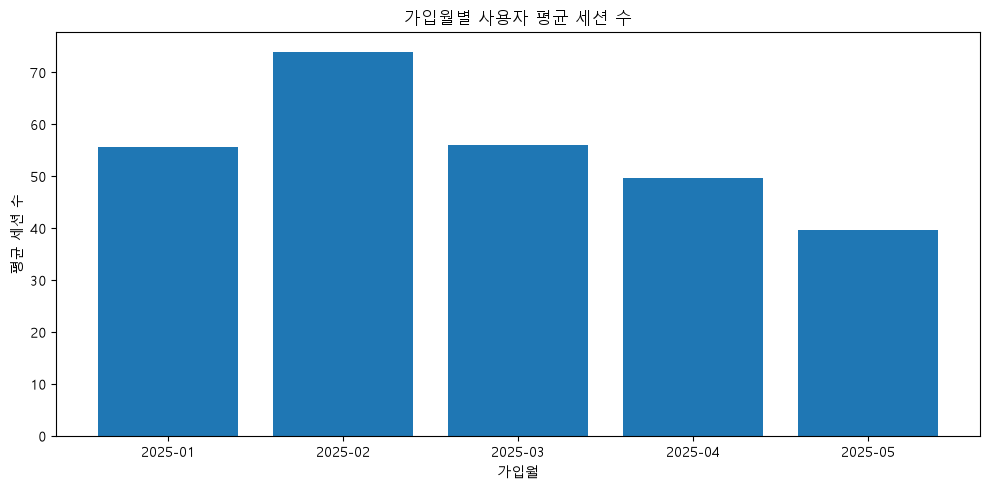

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_session_summary["signup_month"],
    monthly_session_summary["평균세션수"]
)

plt.title("가입월별 사용자 평균 세션 수")
plt.xlabel("가입월")
plt.ylabel("평균 세션 수")
plt.tight_layout()
plt.show()

2월 가입 사용자의 세션 이용이 가장 활발 했고 5월가입 사용자의 누적 세션수가 가장 낮았다.

전체적으로 평균이 중앙값에 비에 값이 많이 높은 편이다.

> 이는 대부분의 사용자는 상대적으로 적은 세션을 보유햇으나 
> 일부 사용자가 많은 활동을 통해 평균을 끌어 올린 것으로 보인다

또한 2월 가입자가 인원 수도 많고 평균과 중앙값이 다른날의 가입자에 비해 모두 높은것으로 보아
일부 사용자가 뿐만아니라 전체 사용자 수준에서도 앱 방문이 활발하게 이루어진 집단으로 볼 수 있다

이벤트 타입 알수없음이 어디서 나오는지 확인

In [41]:
session_df["event_type"].value_counts().head(20)  

event_type
앱실행       718047
수면기록      239437
운동기록      129304
마음챙김      128430
식단기록       99833
챌린지참여      95375
챌린지_탐색     76910
알수없음       22780
온보딩_완료      5644
Name: count, dtype: int64

In [42]:
unknown_event_df = session_df[
    session_df["event_type"] == "알수없음"
].copy()

In [43]:
unknown_event_df

,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing
107,U0000001,2025-02-04 12:17:39,알수없음,dd45570220,NaN,2025-02-04,2025-02,화,12,False,True
323,U0000001,2025-03-07 10:33:01,알수없음,34ae4bdb79,NaN,2025-03-07,2025-03,금,10,False,True
467,U0000001,2025-04-12 21:55:59,알수없음,5fd22b6131,NaN,2025-04-12,2025-04,토,21,False,True
538,U0000002,2025-05-09 12:05:02,알수없음,5c533fdd1a,NaN,2025-05-09,2025-05,금,12,False,True
549,U0000002,2025-05-11 09:39:24,알수없음,c3e6991407,NaN,2025-05-11,2025-05,일,9,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1756881,U0012495,2025-04-13 10:55:04,알수없음,b18dbcafd4,NaN,2025-04-13,2025-04,일,10,False,True
1757085,U0012497,2025-01-29 17:12:30,알수없음,878e7d4ecb,NaN,2025-01-29,2025-01,수,17,False,True
1757176,U0012499,2025-05-13 09:00:25,알수없음,619b01024c,NaN,2025-05-13,2025-05,화,9,False,True
1757191,U0012499,2025-05-18 15:51:00,알수없음,559ecf591c,NaN,2025-05-18,2025-05,일,15,False,True


전체 규모 확인

In [44]:
print("알수없음 이벤트 수:", len(unknown_event_df))
print(
    "전체 이벤트 대비 비율:",
    round(
        len(unknown_event_df) / len(event_df) * 100,
        2
    ),
    "%"
)

print(
    "알수없음 이벤트가 발생한 사용자 수:",
    unknown_event_df["user_id"].nunique()
)

print(
    "알수없음 이벤트가 발생한 세션 수:",
    unknown_event_df["session_id"].nunique()
)

알수없음 이벤트 수: 22780
전체 이벤트 대비 비율: 1.3 %
알수없음 이벤트가 발생한 사용자 수: 6865
알수없음 이벤트가 발생한 세션 수: 22520


월별 발생위치 확인

In [45]:
unknown_by_month = (
    unknown_event_df
    .groupby("event_month")
    .agg(
        알수없음이벤트수=("user_id", "size"),
        사용자수=("user_id", "nunique"),
        세션수=("session_id", "nunique")
    )
    .reset_index()
)

In [46]:
unknown_by_month

,event_month,알수없음이벤트수,사용자수,세션수
0,2025-01,1623,941,1600
1,2025-02,4374,2416,4316
2,2025-03,5041,2676,4970
3,2025-04,5330,2878,5280
4,2025-05,4476,2514,4440
5,2025-06,1936,1001,1914


In [47]:
total_by_month = (
    event_df
    .groupby("event_month")
    .size()
    .reset_index(name="전체이벤트수")
)

unknown_by_month = unknown_by_month.merge(
    total_by_month,
    on="event_month",
    how="left"
)

unknown_by_month["알수없음비율"] = (
    unknown_by_month["알수없음이벤트수"]
    / unknown_by_month["전체이벤트수"]
    * 100
).round(2)

display(unknown_by_month)

,event_month,알수없음이벤트수,사용자수,세션수,전체이벤트수,알수없음비율
0,2025-01,1623,941,1600,117105,1.39
1,2025-02,4374,2416,4316,337154,1.30
2,2025-03,5041,2676,4970,386739,1.30
3,2025-04,5330,2878,5280,420330,1.27
4,2025-05,4476,2514,4440,349351,1.28
5,2025-06,1936,1001,1914,146583,1.32


이벤트 타입중 알수없음(결측치)가 로그 수집이상기간에 몰려있을 것이라 생각하고 진행했으니 생각과는다르게
모든 기간에 분포되어 있음이 확인되었다

여기서 사용자 수는 알수없음 이벤트가 발생한 사용자 수 이며 세션수는 알수없음 이벤트가 나온 세션수 이다


시간대별 확인

In [48]:
unknown_by_hour = (
    unknown_event_df
    .groupby("event_hour")
    .agg(
        알수없음이벤트수=("user_id", "size"),
        사용자수=("user_id", "nunique")
    )
    .reset_index()
)

In [49]:
total_by_hour = (
    event_df
    .groupby("event_hour")
    .size()
    .reset_index(name="전체이벤트수")
)

unknown_by_hour = unknown_by_hour.merge(
    total_by_hour,
    on="event_hour",
    how="left"
)

unknown_by_hour["알수없음비율"] = (
    unknown_by_hour["알수없음이벤트수"]
    / unknown_by_hour["전체이벤트수"]
    * 100
).round(2)

display(unknown_by_hour)

,event_hour,알수없음이벤트수,사용자수,전체이벤트수,알수없음비율
0,7,1416,1232,95320,1.49
1,8,1370,1179,112801,1.21
2,9,1398,1208,112757,1.24
3,10,1407,1239,112468,1.25
4,11,1438,1242,113121,1.27
5,12,1476,1289,113968,1.30
6,13,1462,1250,113141,1.29
7,14,1466,1251,113259,1.29
8,15,1368,1195,112848,1.21
9,16,1456,1249,112252,1.30


요일별 확인

In [50]:
unknown_by_weekday = (
    unknown_event_df
    .groupby("event_weekday")
    .agg(
        알수없음이벤트수=("user_id", "size"),
        사용자수=("user_id", "nunique")
    )
    .reset_index()
)

In [51]:
total_by_weekday = (
    event_df
    .groupby("event_weekday")
    .size()
    .reset_index(name="전체이벤트수")
)

unknown_by_weekday = unknown_by_weekday.merge(
    total_by_weekday,
    on="event_weekday",
    how="left"
)

unknown_by_weekday["알수없음비율"] = (
    unknown_by_weekday["알수없음이벤트수"]
    / unknown_by_weekday["전체이벤트수"]
    * 100
).round(2)

display(unknown_by_weekday)

,event_weekday,알수없음이벤트수,사용자수,전체이벤트수,알수없음비율
0,금,3236,2414,248817,1.30
1,목,3262,2405,247739,1.32
2,수,3129,2359,247063,1.27
3,월,3274,2428,248472,1.32
4,일,3252,2411,258483,1.26
5,토,3364,2449,258973,1.30
6,화,3263,2402,247715,1.32


사용자별 발생 횟수 확인

In [52]:
unknown_by_user = (
    unknown_event_df
    .groupby("user_id")
    .agg(
        알수없음이벤트수=("event_type", "size"),
        세션수=("session_id", "nunique"),
        최초발생일=("event_time", "min"),
        최근발생일=("event_time", "max")
    )
    .reset_index()
    .sort_values(
        "알수없음이벤트수",
        ascending=False
    )
)

display(unknown_by_user.head(30))

,user_id,알수없음이벤트수,세션수,최초발생일,최근발생일
2362,U0004393,16,15,2025-01-01 17:06:34,2025-03-23 17:33:55
3037,U0005637,16,15,2025-02-03 10:28:16,2025-04-17 21:15:49
2030,U0003819,16,16,2025-01-09 19:01:10,2025-04-04 11:08:07
4338,U0007982,16,14,2025-01-16 21:58:20,2025-03-27 13:40:19
3194,U0005948,15,15,2025-02-19 10:00:22,2025-05-15 21:58:20
5068,U0009296,15,15,2025-02-03 11:04:26,2025-05-01 12:43:00
4861,U0008919,15,15,2025-02-06 14:02:32,2025-04-03 15:35:29
4018,U0007377,15,14,2025-04-09 16:03:02,2025-06-30 07:22:02
5008,U0009206,14,14,2025-02-01 21:15:55,2025-04-29 15:11:02
4340,U0007986,14,12,2025-02-06 19:15:19,2025-05-06 12:08:42


In [53]:
unknown_by_user['알수없음이벤트수'].value_counts()

알수없음이벤트수
1     2443
2     1238
3      757
4      564
5      501
6      384
7      304
8      252
9      151
10     119
11      64
12      48
13      20
14      12
16       4
15       4
Name: count, dtype: int64

사용자 프로필과 연결해서 보기

In [54]:
#전체 유저 집계
event_user_detail = event_df.merge(
    user_df[
        [
            "user_id",
            "signup_month",
            "signup_channel",
            "device",
            "notification_agreed"
        ]
    ],
    on="user_id",
    how="left",
    validate="many_to_one"
)

In [55]:
#알수없음 이벤트 발생 유저 집계
unknown_user_detail = unknown_event_df.merge(
    user_df[
        [
            "user_id",
            "signup_month",
            "signup_channel",
            "device",
            "notification_agreed"
        ]
    ],
    on="user_id",
    how="left",
    validate="many_to_one"
)

In [56]:
#가입 연월

# 알수없음 이벤트 집계
unknown_by_signup_month = (
    unknown_user_detail
    .groupby("signup_month")
    .agg(
        알수없음이벤트수=("user_id", "size"),
        알수없음사용자수=("user_id", "nunique")
    )
    .reset_index()
)

# 전체 이벤트 집계
total_by_signup_month = (
    event_user_detail
    .groupby("signup_month")
    .agg(
        전체이벤트수=("user_id", "size")
    )
    .reset_index()
)

# 전체 사용자 집계
total_user_by_signup_month = (
    user_df
    .groupby("signup_month")
    .agg(
        전체사용자수=("user_id", "nunique")
    )
    .reset_index()
)

# 결합
unknown_by_signup_month = (
    unknown_by_signup_month
    .merge(
        total_by_signup_month,
        on="signup_month",
        how="left"
    )
    .merge(
        total_user_by_signup_month,
        on="signup_month",
        how="left"
    )
)

# 비율 계산
unknown_by_signup_month["알수없음이벤트비율"] = (
    unknown_by_signup_month["알수없음이벤트수"]
    / unknown_by_signup_month["전체이벤트수"]
    * 100
).round(2)

unknown_by_signup_month["알수없음사용자비율"] = (
    unknown_by_signup_month["알수없음사용자수"]
    / unknown_by_signup_month["전체사용자수"]
    * 100
).round(2)

display(unknown_by_signup_month)

,signup_month,알수없음이벤트수,알수없음사용자수,전체이벤트수,전체사용자수,알수없음이벤트비율,알수없음사용자비율
0,2025-01,3797,1181,284837,2124,1.33,55.60
1,2025-02,9835,2597,772291,4384,1.27,59.24
2,2025-03,3673,1116,281984,2122,1.30,52.59
3,2025-04,3241,1079,248796,2082,1.30,51.83
4,2025-05,2234,892,169354,1788,1.32,49.89


In [57]:
#기기별 확인
# 알수없음 이벤트 집계
unknown_by_device = (
    unknown_user_detail
    .groupby("device")
    .agg(
        알수없음이벤트수=("user_id", "size"),
        알수없음사용자수=("user_id", "nunique")
    )
    .reset_index()
)

# 전체 이벤트 집계
total_by_device = (
    event_user_detail
    .groupby("device")
    .agg(
        전체이벤트수=("user_id", "size")
    )
    .reset_index()
)

# 전체 사용자 집계
total_user_by_device = (
    user_df
    .groupby("device")
    .agg(
        전체사용자수=("user_id", "nunique")
    )
    .reset_index()
)

# 결합
unknown_by_device = (
    unknown_by_device
    .merge(
        total_by_device,
        on="device",
        how="left"
    )
    .merge(
        total_user_by_device,
        on="device",
        how="left"
    )
)

# 비율 계산
unknown_by_device["알수없음이벤트비율"] = (
    unknown_by_device["알수없음이벤트수"]
    / unknown_by_device["전체이벤트수"]
    * 100
).round(2)

unknown_by_device["알수없음사용자비율"] = (
    unknown_by_device["알수없음사용자수"]
    / unknown_by_device["전체사용자수"]
    * 100
).round(2)

unknown_by_device = (
    unknown_by_device
    .sort_values(
        "알수없음이벤트비율",
        ascending=False
    )
    .reset_index(drop=True)
)

display(unknown_by_device)

,device,알수없음이벤트수,알수없음사용자수,전체이벤트수,전체사용자수,알수없음이벤트비율,알수없음사용자비율
0,Android,9686,2883,735919,5204,1.32,55.40
1,iOS,12857,3914,1003320,7175,1.28,54.55


In [58]:
#가입 경로별
# 알수없음 이벤트 집계
unknown_by_channel = (
    unknown_user_detail
    .groupby("signup_channel")
    .agg(
        알수없음이벤트수=("user_id", "size"),
        알수없음사용자수=("user_id", "nunique")
    )
    .reset_index()
)

# 전체 이벤트 집계
total_by_channel = (
    event_user_detail
    .groupby("signup_channel")
    .agg(
        전체이벤트수=("user_id", "size")
    )
    .reset_index()
)

# 전체 사용자 집계
total_user_by_channel = (
    user_df
    .groupby("signup_channel")
    .agg(
        전체사용자수=("user_id", "nunique")
    )
    .reset_index()
)

# 결합
unknown_by_channel = (
    unknown_by_channel
    .merge(
        total_by_channel,
        on="signup_channel",
        how="left"
    )
    .merge(
        total_user_by_channel,
        on="signup_channel",
        how="left"
    )
)

# 비율 계산
unknown_by_channel["알수없음이벤트비율"] = (
    unknown_by_channel["알수없음이벤트수"]
    / unknown_by_channel["전체이벤트수"]
    * 100
).round(2)

unknown_by_channel["알수없음사용자비율"] = (
    unknown_by_channel["알수없음사용자수"]
    / unknown_by_channel["전체사용자수"]
    * 100
).round(2)

unknown_by_channel = (
    unknown_by_channel
    .sort_values(
        "알수없음이벤트비율",
        ascending=False
    )
    .reset_index(drop=True)
)

display(unknown_by_channel)

,signup_channel,알수없음이벤트수,알수없음사용자수,전체이벤트수,전체사용자수,알수없음이벤트비율,알수없음사용자비율
0,오가닉,10137,3038,780722,5511,1.30,55.13
1,퍼포먼스광고,12395,3747,957229,6852,1.29,54.68


알수없음(결측치)가 수집 누락 부분에 몰려있을 거라고 가정했던 초반과는 달리 알수없음은 
2월에 많이 발생하였으나 이벤트 비율은 오히려 가장 적고
 그외에는 고르게 분포가 되어있는 상황이였다.

그래서 이 이벤트가 특정 유저에게 몰려있나 확인해본 결과 소수의 유저를 제외한 대다수의 유저에게 고르게 발견되는 것을 확인했다.


그럼 기기에 따른 알수없는이벤트 발생비율을 살펴 봣을때 안드로이드 55.4 iOS 54.55로 비슷한 비율이였고

가입경로에 따른 비율도 오가닉 55.13, 퍼포먼스 광고도 54.68로 비슷한 비율이 나오는 걸 확인할 수있었다


# 알수없음이 발생한 사람들의 리텐션 비율 확인

이벤트 타입 결측치 처리

In [59]:
event_df = event_df.copy()

event_df["event_type"] = (
    event_df["event_type"]
    .fillna("알수없음")
)

print(
    "event_type 남은 결측치 수:",
    event_df["event_type"].isna().sum()
)

event_type 남은 결측치 수: 0


세션 아이디가 있는 이벤트만 선택

In [60]:
session_event_df = event_df[
    event_df["session_id"].notna()
].copy()

print("전체 이벤트 수:", len(event_df))
print("session_id가 있는 이벤트 수:", len(session_event_df))
print(
    "session_id가 있는 이벤트 비율:",
    round(
        len(session_event_df)
        / len(event_df)
        * 100,
        2
    ),
    "%"
)

전체 이벤트 수: 1757262
session_id가 있는 이벤트 수: 1515760
session_id가 있는 이벤트 비율: 86.26 %


이벤트 데이터에 사용자 정보 결합

In [61]:
event_user_df = event_df.merge(
    user_df[
        [
            "user_id",
            "signup_date",
            "signup_month",
            "signup_channel",
            "device",
            "notification_agreed"
        ]
    ],
    on="user_id",
    how="left",
    validate="many_to_one"
)

가입 후 경과일 계산

In [62]:
event_user_df["가입후경과일"] = (
    event_user_df["event_date"]
    - event_user_df["signup_date"]
).dt.days

In [63]:
display(
    event_user_df[
        [
            "user_id",
            "signup_date",
            "event_date",
            "event_type",
            "가입후경과일"
        ]
    ].head()
)

,user_id,signup_date,event_date,event_type,가입후경과일
0,U0000001,2025-01-25,2025-01-25,앱실행,0
1,U0000001,2025-01-25,2025-01-25,온보딩_완료,0
2,U0000001,2025-01-25,2025-01-25,챌린지_탐색,0
3,U0000001,2025-01-25,2025-01-25,챌린지참여,0
4,U0000001,2025-01-25,2025-01-25,알림수신,0


전체 알수없음 경험 사용자 확인

In [64]:
unknown_users = (
    event_user_df.loc[
        event_user_df["event_type"] == "알수없음",
        "user_id"
    ]
    .dropna()
    .unique()
)

In [88]:
print('전체 이벤트 수 :', len(event_user_df))

print(
    "알수없음 이벤트 수:",
    (
        event_user_df["event_type"]
        == "알수없음"
    ).sum()
)

print(
    "알수없음 경험 사용자 수:",
    len(unknown_users)
)

전체 이벤트 수 : 1757262
알수없음 이벤트 수: 26456
알수없음 경험 사용자 수: 7206


사용자별 알수없음 경험여부 생성

In [66]:
retention_user_df = user_df.copy()

retention_user_df["알수없음경험여부"] = (
    retention_user_df["user_id"]
    .isin(unknown_users)
)

In [67]:
print(
    retention_user_df["알수없음경험여부"]
    .value_counts()
)

print(
    retention_user_df["알수없음경험여부"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

알수없음경험여부
True     7206
False    5294
Name: count, dtype: int64
알수없음경험여부
True     57.65
False    42.35
Name: proportion, dtype: float64


일제 사용자 활동 이벤트 정의

In [68]:
activity_events = [
    "앱실행",
    "온보딩_완료",
    "챌린지_탐색",
    "챌린지참여",
    "수면기록",
    "운동기록",
    "마음챙김",
    "식단기록",
    "알림오픈"
]

In [69]:
activity_df = event_user_df[
    event_user_df["event_type"]
    .isin(activity_events)
].copy()

D·D7·D14·D30 리텐션 여부 생성

In [70]:
retention_days = [
    3,
    7,
    30
]

In [71]:
for day in retention_days:

    retained_users = (
        activity_df.loc[
            activity_df["가입후경과일"] == day,
            "user_id"
        ]
        .dropna()
        .unique()
    )

    retention_user_df[f"D{day}_리텐션"] = (
        retention_user_df["user_id"]
        .isin(retained_users)
    )

관찰이 가능한 사용자만 포함

In [72]:
data_end_date = event_user_df["event_date"].max()

retention_user_df["signup_date"] = pd.to_datetime(
    retention_user_df["signup_date"],
    errors="coerce"
)

retention_user_df["관찰가능일수"] = (
    data_end_date
    - retention_user_df["signup_date"]
).dt.days

알수없음 경험 여부별 리텐션 계산

In [73]:
retention_result_list = []

for day in retention_days:

    eligible_df = retention_user_df[
        retention_user_df["관찰가능일수"] >= day
    ].copy()

    summary = (
        eligible_df
        .groupby("알수없음경험여부")
        .agg(
            대상사용자수=("user_id", "nunique"),
            리텐션사용자수=(f"D{day}_리텐션", "sum")
        )
        .reset_index()
    )

    summary["리텐션일"] = f"D{day}"

    summary["리텐션율"] = (
        summary["리텐션사용자수"]
        / summary["대상사용자수"]
        * 100
    ).round(2)

    retention_result_list.append(summary)

In [74]:
unknown_retention_summary = pd.concat(
    retention_result_list,
    ignore_index=True
)

In [75]:
unknown_retention_summary["그룹"] = (
    unknown_retention_summary[
        "알수없음경험여부"
    ]
    .map(
        {
            True: "알수없음 경험",
            False: "알수없음 미경험"
        }
    )
)

In [76]:
unknown_retention_summary = (
    unknown_retention_summary[
        [
            "그룹",
            "리텐션일",
            "대상사용자수",
            "리텐션사용자수",
            "리텐션율"
        ]
    ]
    .sort_values(
        [
            "리텐션일",
            "그룹"
        ]
    )
    .reset_index(drop=True)
)

display(unknown_retention_summary)

,그룹,리텐션일,대상사용자수,리텐션사용자수,리텐션율
0,알수없음 경험,D3,7206,6502,90.23
1,알수없음 미경험,D3,5294,2499,47.20
2,알수없음 경험,D30,7206,2977,41.31
3,알수없음 미경험,D30,5294,67,1.27
4,알수없음 경험,D7,7206,4448,61.73
5,알수없음 미경험,D7,5294,849,16.04


In [79]:
event_user_df[event_user_df['event_type'] == '알수없음']

,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_date,signup_month,signup_channel,device,notification_agreed,가입후경과일
107,U0000001,2025-02-04 12:17:39,알수없음,dd45570220,NaN,2025-02-04,2025-02,화,12,False,True,2025-01-25,2025-01,오가닉,iOS,True,10
323,U0000001,2025-03-07 10:33:01,알수없음,34ae4bdb79,NaN,2025-03-07,2025-03,금,10,False,True,2025-01-25,2025-01,오가닉,iOS,True,41
467,U0000001,2025-04-12 21:55:59,알수없음,5fd22b6131,NaN,2025-04-12,2025-04,토,21,False,True,2025-01-25,2025-01,오가닉,iOS,True,77
538,U0000002,2025-05-09 12:05:02,알수없음,5c533fdd1a,NaN,2025-05-09,2025-05,금,12,False,True,2025-05-06,2025-05,오가닉,iOS,False,3
549,U0000002,2025-05-11 09:39:24,알수없음,c3e6991407,NaN,2025-05-11,2025-05,일,9,False,True,2025-05-06,2025-05,오가닉,iOS,False,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1756881,U0012495,2025-04-13 10:55:04,알수없음,b18dbcafd4,NaN,2025-04-13,2025-04,일,10,False,True,2025-01-31,2025-01,오가닉,iOS,False,72
1757085,U0012497,2025-01-29 17:12:30,알수없음,878e7d4ecb,NaN,2025-01-29,2025-01,수,17,False,True,2025-01-28,2025-01,오가닉,Android,False,1
1757176,U0012499,2025-05-13 09:00:25,알수없음,619b01024c,NaN,2025-05-13,2025-05,화,9,False,True,2025-05-07,2025-05,오가닉,Android,True,6
1757191,U0012499,2025-05-18 15:51:00,알수없음,559ecf591c,NaN,2025-05-18,2025-05,일,15,False,True,2025-05-07,2025-05,오가닉,Android,True,11


In [94]:
event_user_df[event_user_df['session_id'] == '619b01024c']


,user_id,event_time,event_type,session_id,notification_type,event_date,event_month,event_weekday,event_hour,is_log_issue_period,is_event_type_missing,signup_date,signup_month,signup_channel,device,notification_agreed,가입후경과일
1757176,U0012499,2025-05-13 09:00:25,알수없음,619b01024c,NaN,2025-05-13,2025-05,화,9,False,True,2025-05-07,2025-05,오가닉,Android,True,6
1757177,U0012499,2025-05-13 09:00:55,식단기록,619b01024c,NaN,2025-05-13,2025-05,화,9,False,False,2025-05-07,2025-05,오가닉,Android,True,6
